# Phase 1: the discrete event simulation

This notebook runs the hoist circuit simulation built in `src/twin/`, checks that its behaviour makes sense, and compares its output against the synthetic twelve month target built in `src/twin/synthetic_target.py`.

There is no real historical tonnage data available for this project, so the target used here is invented, grounded in published figures for comparable shaft hoisting systems and known Australian mining seasonality rather than picked arbitrarily. The reasoning, the research sources, and the tuning process that got the simulation to track this target are all written up in `phase1_plan.md` and `reports/simulation_validation.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from twin.simulation import load_config, run_simulation
from twin.scenarios import run_scenario
from twin.synthetic_target import build_synthetic_target, MONTH_NAMES

config = load_config(str(PROJECT_ROOT / "config.yaml"))
config

{'seed': 42,
 'simulation': {'horizon_days': 365},
 'sources': {'source_a': {'feed_rate_tph': 420},
  'source_b': {'feed_rate_tph': 380},
  'switch_interval_hours': 8},
 'bins': {'count': 3, 'capacity_tonnes': 200},
 'flasks': {'capacity_tonnes': 15},
 'skips': {'count': 2,
  'payload_tonnes': 12,
  'load_time_mean_s': 20,
  'hoist_time_mean_s': 60,
  'dump_time_mean_s': 10,
  'return_time_mean_s': 55,
  'cycle_time_cv': 0.1},
 'winder': {'scheduled_downtime_hours_per_month': 20,
  'breakdown_mtbf_hours': 200,
  'breakdown_mttr_hours': 4,
  'scheduled_downtime_overrides': {0: 288, 6: 355, 11: 280}},
 'paths': {'data_raw': 'data/raw',
  'data_processed': 'data/processed',
  'reports': 'reports'}}

## Run one scenario

A single replication, using the seed from `config.yaml`. This is enough to look at the cycle time distribution and the bin level dynamics, since those are about the shape of behaviour within one run, not about averaging out randomness across runs.

In [2]:
result = run_simulation(config, seed=config["seed"])

print(f"total tonnes over {config['simulation']['horizon_days']} days: {result.total_tonnes:,.0f}")
print(f"winder utilisation: {result.winder_utilisation_pct:.1f}%")
print(f"winder downtime: {result.winder_downtime_pct:.1f}%")
print(f"skip cycles completed: {len(result.cycle_log):,}")
print()
print("monthly tonnes (month 12 is a partial month, the horizon is not a multiple of 30 days):")
result.monthly_tonnes

total tonnes over 365 days: 2,579,988
winder utilisation: 85.2%
winder downtime: 14.8%
skip cycles completed: 214,999

monthly tonnes (month 12 is a partial month, the horizon is not a multiple of 30 days):


month
0     144612
1     233136
2     236424
3     236004
4     235740
5     236880
6     120396
7     241632
8     238116
9     236064
10    241224
11    145524
12     34236
Name: tonnes, dtype: int64

## Bin levels over time

Each of the three ore bins should stay within its 200 tonne capacity, and should visibly build up toward capacity during the calendar downtime blocks in January, July, and December, since ore keeps arriving from the sources while the winder is not clearing it.

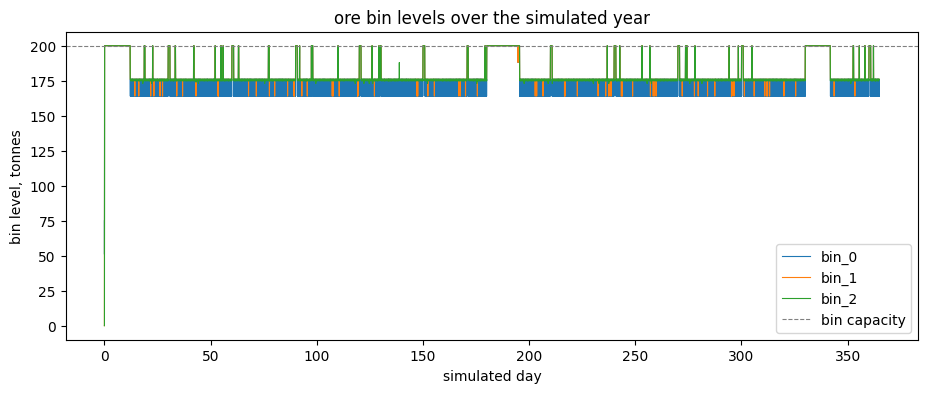

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for bin_name, group in result.bin_level_log.groupby("bin_name"):
    ax.plot(group["time_s"] / (24 * 3600), group["level_tonnes"], label=bin_name, linewidth=0.8)
ax.axhline(config["bins"]["capacity_tonnes"], color="grey", linestyle="--", linewidth=0.8, label="bin capacity")
ax.set_xlabel("simulated day")
ax.set_ylabel("bin level, tonnes")
ax.set_title("ore bin levels over the simulated year")
ax.legend()
plt.show()

## Skip cycle time distribution

West and east should look similar, since they are configured identically, and each skip's cycle time should be noticeably longer than the roughly 145 second solo estimate from the research, because the winder is shared and busy about 95 percent of the time, so a skip spends real time queueing for its turn.

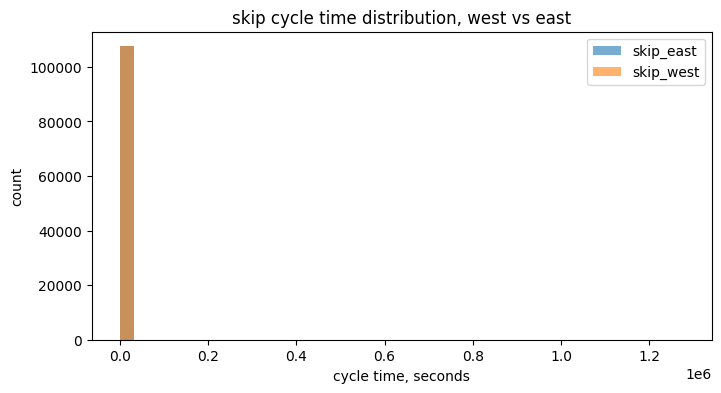

,count,mean,std,min,25%,50%,75%,max
skip_name,,,,,,,,
skip_east,107500.0,293.358136,5939.823213,200.665050,242.215985,249.959873,257.817977,1.278255e+06
skip_west,107499.0,293.359740,5940.124757,195.196112,242.172494,249.986443,257.838519,1.278268e+06


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for skip_name, group in result.cycle_log.groupby("skip_name"):
    ax.hist(group["cycle_time_s"], bins=40, alpha=0.6, label=skip_name)
ax.set_xlabel("cycle time, seconds")
ax.set_ylabel("count")
ax.set_title("skip cycle time distribution, west vs east")
ax.legend()
plt.show()

result.cycle_log.groupby("skip_name")["cycle_time_s"].describe()

## Monthly tonnes against the synthetic target

This uses 20 replications rather than one, since comparing against a monthly target should use the simulation's expected behaviour, not one noisy realisation. Each replication uses a different seed. The confidence interval comes from a t distribution across replication means, which is appropriate for the 20 to 30 replications used here rather than the thousands where a normal approximation would be fine.

In [5]:
scenario = run_scenario(config, n_replications=20, base_seed=100)

print(f"mean monthly tonnes across 20 replications: {scenario.mean_monthly_tonnes:,.0f}")
print(f"95% confidence interval: [{scenario.ci_low:,.0f}, {scenario.ci_high:,.0f}]")
print(f"mean winder utilisation: {scenario.mean_winder_utilisation_pct:.1f}%")

target = build_synthetic_target()
sim_monthly = scenario.monthly_tonnes_by_replication.mean(axis=0)
sim_monthly.index = MONTH_NAMES[: len(sim_monthly)]

comparison = target.to_frame("synthetic_target").join(sim_monthly.rename("simulated"))
comparison["pct_diff"] = (comparison["simulated"] - comparison["synthetic_target"]) / comparison["synthetic_target"] * 100
comparison

mean monthly tonnes across 20 replications: 212,739
95% confidence interval: [212,303, 213,175]
mean winder utilisation: 85.4%


,synthetic_target,simulated,pct_diff
Jan,140195.921533,145417.2,3.724273
Feb,230380.100338,237864.6,3.248761
Mar,239861.717609,236374.2,-1.453970
Apr,228893.391995,237071.4,3.572846
May,237680.322802,237455.4,-0.094632
Jun,234453.461865,238870.8,1.884100
Jul,125740.812788,123084.6,-2.112451
Aug,237140.981501,237631.8,0.206973
Sep,228230.917684,238465.8,4.484442
Oct,235741.922162,236979.6,0.525014


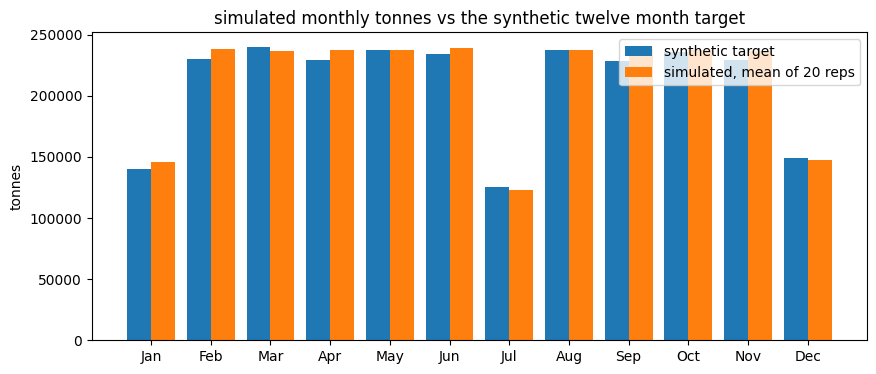

months within 5%: 12 / 12


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(comparison))
ax.bar([i - 0.2 for i in x], comparison["synthetic_target"], width=0.4, label="synthetic target")
ax.bar([i + 0.2 for i in x], comparison["simulated"], width=0.4, label="simulated, mean of 20 reps")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index)
ax.set_ylabel("tonnes")
ax.set_title("simulated monthly tonnes vs the synthetic twelve month target")
ax.legend()
plt.show()

within_5pct = (comparison["pct_diff"].abs() <= 5).sum()
print(f"months within 5%: {within_5pct} / 12")